In [22]:
# Install requirements
%pip install matplotlib numpy pandas nltk pillow

Note: you may need to restart the kernel to use updated packages.


In [1]:
import csv
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nltk.corpus import wordnet


In [24]:
df = pd.read_csv('surveyDataScience.csv', low_memory=False)
df.head()

,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,Q7_Part_3,...,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_8,Q38_B_Part_9,Q38_B_Part_10,Q38_B_Part_11,Q38_B_OTHER
0,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,What is the highest level of formal education ...,Select the title most similar to your current ...,For how many years have you been writing code ...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,...,"In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor..."
1,910,50-54,Man,India,Bachelor’s degree,Other,5-10 years,Python,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,784,50-54,Man,Indonesia,Master’s degree,Program/Project Manager,20+ years,NaN,NaN,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,924,22-24,Man,Pakistan,Master’s degree,Software Engineer,1-3 years,Python,NaN,NaN,...,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
questions = df.columns.str.split(r'(_Part|_OTHER|_A|_B).*').str[0]
questions.unique()

Index(['Time from Start to Finish (seconds)', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5',
       'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16',
       'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26',
       'Q27', 'Q28', 'Q29', 'Q30', 'Q31', 'Q32', 'Q33', 'Q34', 'Q35', 'Q36',
       'Q37', 'Q38', 'Q39', 'Q40', 'Q41', 'Q42'],
      dtype='str')

In [26]:
number_responses = len(df)
number_responses

25974

In [27]:
number_attributes = len(df.columns)
number_attributes

369

In [28]:
df.dtypes

Time from Start to Finish (seconds)    str
Q1                                     str
Q2                                     str
Q3                                     str
Q4                                     str
                                      ... 
Q38_B_Part_8                           str
Q38_B_Part_9                           str
Q38_B_Part_10                          str
Q38_B_Part_11                          str
Q38_B_OTHER                            str
Length: 369, dtype: object

In [29]:
complete_rows = df[1:].notna().T.groupby(questions).any().T.all(axis=1).sum()
complete_rows

np.int64(201)

In [30]:
education_map = {
    "Bachelor's degree": 3,
    "Master's degree": 5,
    "Doctoral degree": 8,
    "Professional doctorate": 8,
    "Some college/university study without earning a bachelor’s degree": 1,
    "No formal education past high school": 0,
    "I prefer not to answer": None
}

avg_education = df['Q4'][1:].map(education_map).dropna().mean()
avg_education

np.float64(5.082909364989637)

In [31]:
ro_df = df[df['Q3'] == 'Romania']
avg_ro_education = ro_df['Q4'][1:].map(education_map).dropna().mean()
avg_ro_education

np.float64(5.166666666666667)

In [32]:
ro_w_df = ro_df[ro_df['Q2'] == 'Woman']
avg_ro_w_education = ro_w_df['Q4'][1:].map(education_map).dropna().mean()
avg_ro_w_education

np.float64(6.25)

In [33]:
complete_ro_w_rows = ro_w_df[1:].notna().T.groupby(questions).any().T.all(axis=1).sum()
complete_ro_w_rows

np.int64(0)

In [34]:
ro_Python_w_df = ro_w_df[ro_w_df['Q7_Part_1'] == 'Python']
ro_Python_w_df.shape[0]

12

In [35]:
ro_Python_w_df['Q1'].mode()[0]

'35-39'

In [37]:
ro_Cpp_w_df['Q1'].mode()[0]

'18-21'

In [36]:
ro_Cpp_w_df = ro_w_df[ro_w_df['Q7_Part_5'] == 'C++']
ro_Cpp_w_df.shape[0]

4

In [ ]:
min(time_s)

120

In [38]:
non_numeric = df[1:].drop(columns=['Time from Start to Finish (seconds)'])
non_numeric.nunique()

Q1               11
Q2                5
Q3               66
Q4                7
Q5               15
                 ..
Q38_B_Part_8      1
Q38_B_Part_9      1
Q38_B_Part_10     1
Q38_B_Part_11     0
Q38_B_OTHER       1
Length: 368, dtype: int64

In [39]:
time_s = pd.to_numeric(df['Time from Start to Finish (seconds)'].iloc[1:])
max(time_s)

2488653

In [41]:
data = df.iloc[1:].copy()
exp_map = {
    'I have never written code': 0,
    '< 1 years': 0.5,
    '1-3 years': 2,
    '3-5 years': 4,
    '5-10 years': 7.5,
    '10-20 years': 15,
    '20+ years': 25
}
data['Years_Exp'] = data['Q6'].map(exp_map)
print("Minim", data['Years_Exp'].min())
print("Maxim", data['Years_Exp'].max())
print("Mean", data['Years_Exp'].mean())
print("Standard deviation", data['Years_Exp'].std())
print("Median", data['Years_Exp'].median())

Minim 0.0
Maxim 25.0
Mean 5.281061101913526
Standard deviation 6.79090316922895
Median 2.0


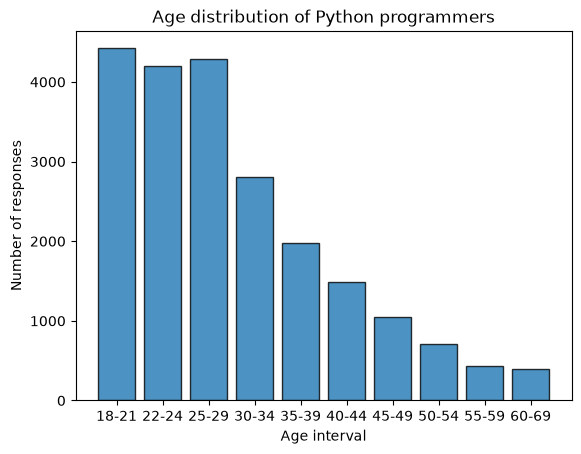

In [42]:
df_Python = df[df['Q7_Part_1'] == 'Python']
bin_edges = [k-0.5 for k in range(len(df_Python['Q1'].unique()))]
plt.hist(df_Python['Q1'].sort_values().dropna(), bins=bin_edges, alpha=0.8, rwidth=0.8, edgecolor='k')
plt.xlabel('Age interval')
plt.ylabel('Number of responses')
plt.title("Age distribution of Python programmers")
plt.show()

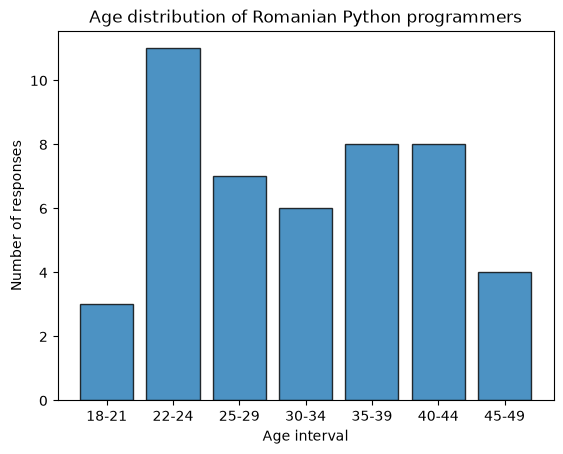

In [43]:
df_ro_Python = df_Python[df_Python['Q3'] == 'Romania']
bin_edges1 = [k-0.5 for k in range(len(df_ro_Python['Q1'].unique()))]
plt.hist(df_ro_Python['Q1'].sort_values(), bins=bin_edges1, alpha=0.8, rwidth=0.8, edgecolor='k')
plt.xlabel('Age interval')
plt.ylabel('Number of responses')
plt.title("Age distribution of Romanian Python programmers")
plt.show()

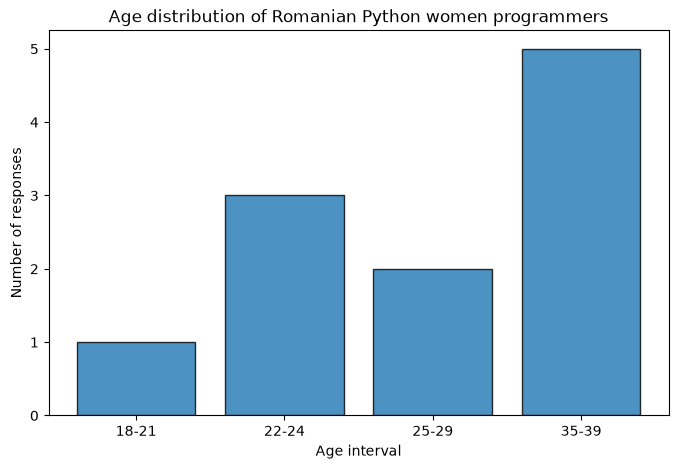

In [44]:
bin_edges2 = [k-0.5 for k in range(len(ro_Python_w_df['Q1'].unique()))]
fig = plt.figure(figsize=(8,5))
plt.hist(ro_Python_w_df['Q1'].sort_values().dropna(), bins=bin_edges2, alpha=0.8, rwidth=0.8, edgecolor='k')
plt.xlabel('Age interval')
plt.ylabel('Number of responses')
plt.title("Age distribution of Romanian Python women programmers")
plt.show()

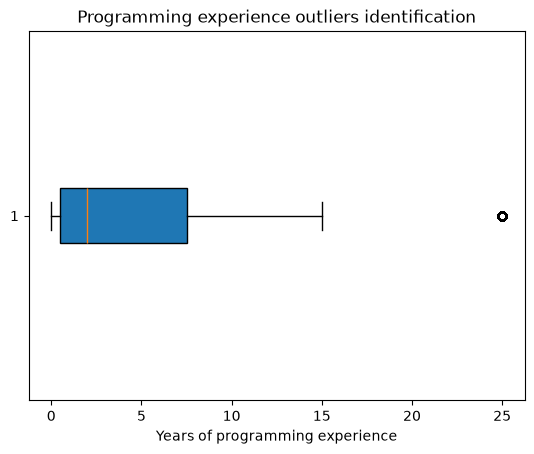

In [48]:
plt.boxplot(data['Q6'].map(exp_map).dropna(), orientation="horizontal", patch_artist=True)
plt.title('Programming experience outliers identification')
plt.xlabel('Years of programming experience')
plt.show()

- Grid of images: 


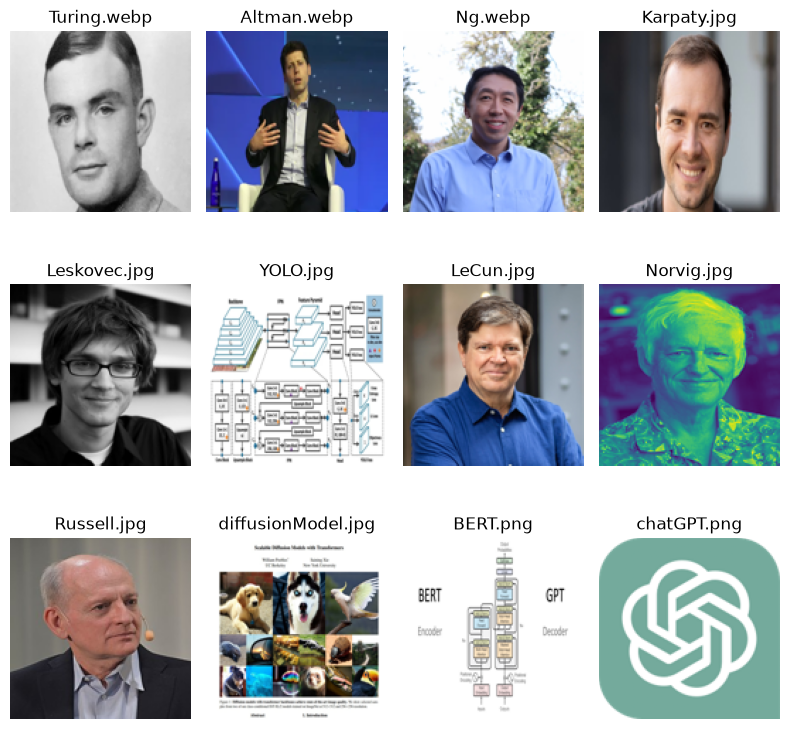

- Images transformed to gray-levels: 


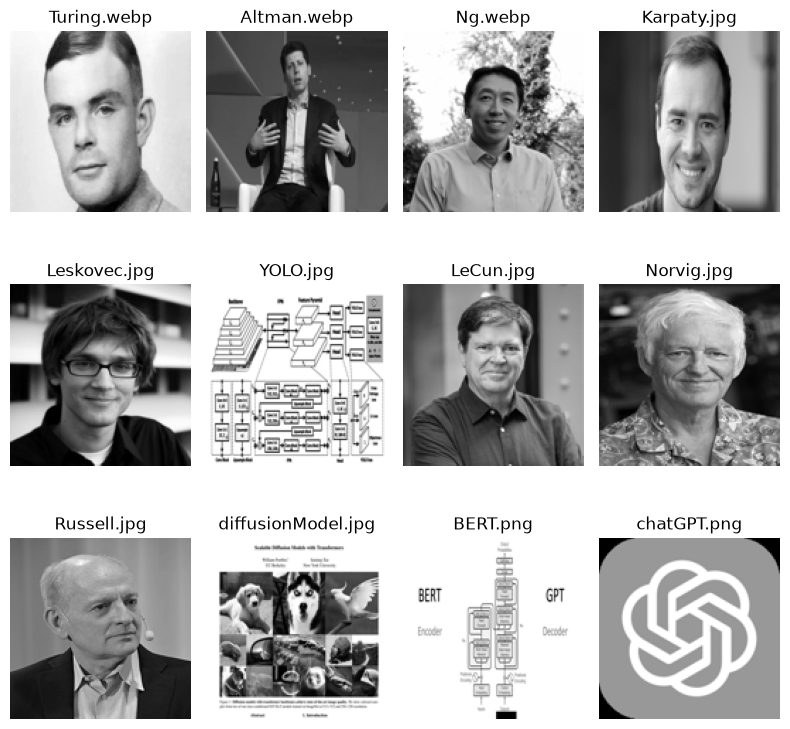

- Image BLUR before/after: 


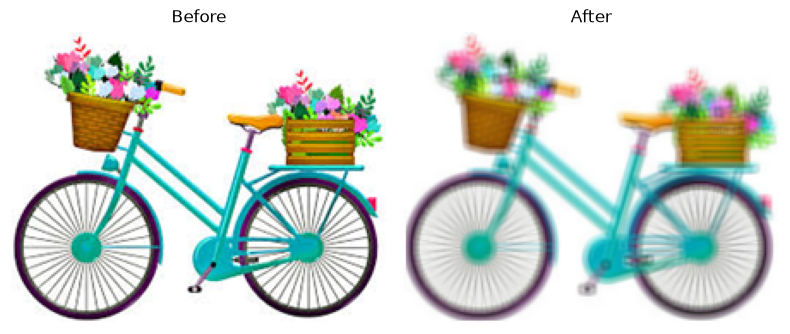

- Image FIND EDGES before/after: 


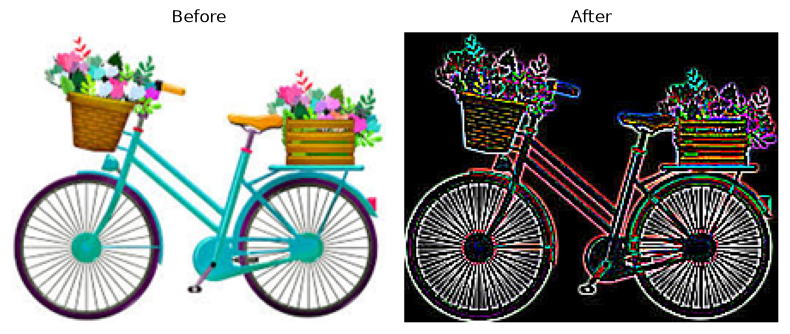

In [52]:
from pathlib import Path

from matplotlib import pyplot as plt
from numpy import asarray
from PIL import Image, ImageFilter


def imageProcessing():
    im = Image.open('bike.png')
    im.show()

    print("- Grid of images: ")
    basePath = Path.cwd()
    imagesDir = basePath.joinpath('images')
    imagePaths = list(imagesDir.glob('*.webp')) + list(imagesDir.glob('*.jpg')) + list(imagesDir.glob('*.png'))

    _, axs = plt.subplots(3, 4, figsize=(8, 8))
    for i, ax in enumerate(axs.flatten()):
        if i < len(imagePaths):
            with Image.open(imagePaths[i]) as image:
                img_resized = image.resize((128, 128))
                ax.imshow(asarray(img_resized))
            ax.set_title(imagePaths[i].name)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    print("- Images transformed to gray-levels: ")
    _, axs = plt.subplots(3, 4, figsize=(8, 8))
    for i, ax in enumerate(axs.flatten()):
        if i < len(imagePaths):
            with Image.open(imagePaths[i]) as image:
                img_resized = image.convert('L').resize((128, 128))
                ax.imshow(asarray(img_resized), cmap='gray')
            ax.set_title(imagePaths[i].name)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    print("- Image BLUR before/after: ")
    _, axs = plt.subplots(1, 2, figsize=(8, 8))
    with Image.open('bike.png') as image:
        modified_image = image.filter(ImageFilter.BLUR)
        axs[0].imshow(asarray(image))
        axs[0].set_title("Before")
        axs[0].axis('off')
        axs[1].imshow(asarray(modified_image))
        axs[1].set_title("After")
        axs[1].axis('off')
    plt.tight_layout()
    plt.show()

    print("- Image FIND EDGES before/after: ")
    _, axs = plt.subplots(1, 2, figsize=(8, 8))
    with Image.open('bike.png') as image:
        modified_image = image.filter(ImageFilter.FIND_EDGES)
        axs[0].imshow(asarray(image))
        axs[0].set_title("Before")
        axs[0].axis('off')
        axs[1].imshow(asarray(modified_image))
        axs[1].set_title("After")
        axs[1].axis('off')
    plt.tight_layout()
    plt.show()
imageProcessing()

In [53]:
from statistics import stdev, mean

def minMax(features):
    minVal, maxVal = min(features), max(features)
    return [(x - minVal) / (maxVal - minVal) for x in features]

def statisticalNormalisation(features):
    m, s = mean(features), stdev(features)
    return [(x - m) / s for x in features]

data['Education_minMax'] = minMax(data['Q4'].map(education_map).fillna(0))
data['Education_statNorm'] = statisticalNormalisation(data['Q4'].map(education_map).fillna(0))
data['Experience_minMax'] = minMax(data['Q6'].map(exp_map).fillna(0))
data['Experience_statNorm'] = statisticalNormalisation(data['Q6'].map(exp_map).fillna(0))

print(data[['Education_minMax', 'Education_statNorm', 'Experience_minMax', 'Experience_statNorm']].head())

   Education_minMax  Education_statNorm  Experience_minMax  \
1               0.0           -0.399375               0.30   
2               0.0           -0.399375               1.00   
3               0.0           -0.399375               0.08   
4               1.0            2.676947               1.00   
5               1.0            2.676947               0.02   

   Experience_statNorm  
1             0.326752  
2             2.903728  
3            -0.483155  
4             2.903728  
5            -0.704039  


In [54]:
basePath = Path.cwd()
imagesDir = basePath.joinpath('images')
imagePaths = list(imagesDir.glob('*.webp')) + list(imagesDir.glob('*.jpg')) + list(imagesDir.glob('*.png'))

all_images_norm = []

for path in imagePaths:
    img = Image.open(path).convert('RGB')
    pixels = np.array(img) / 255.0
    flattened = pixels.reshape(-1, 3)
    all_images_norm.append(flattened)

print(all_images_norm[0][:5])

[[0.94117647 0.94117647 0.94117647]
 [0.93333333 0.93333333 0.93333333]
 [0.91764706 0.91764706 0.91764706]
 [0.90980392 0.90980392 0.90980392]
 [0.91372549 0.91372549 0.91372549]]


In [56]:
imagePaths = list(imagesDir.glob('*.webp')) + list(imagesDir.glob('*.jpg')) + list(imagesDir.glob('*.png'))

all_images_norm = []

for path in imagePaths:
    img = Image.open(path).convert('RGB')
    pixels = np.array(img) / 255.0
    flattened = pixels.reshape(-1, 3)
    all_images_norm.append(flattened)

print(all_images_norm[0][:5])

[[0.94117647 0.94117647 0.94117647]
 [0.93333333 0.93333333 0.93333333]
 [0.91764706 0.91764706 0.91764706]
 [0.90980392 0.90980392 0.90980392]
 [0.91372549 0.91372549 0.91372549]]
